In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (adjusted_rand_score, completeness_score,
                             homogeneity_score, normalized_mutual_info_score,
                             silhouette_score)
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer

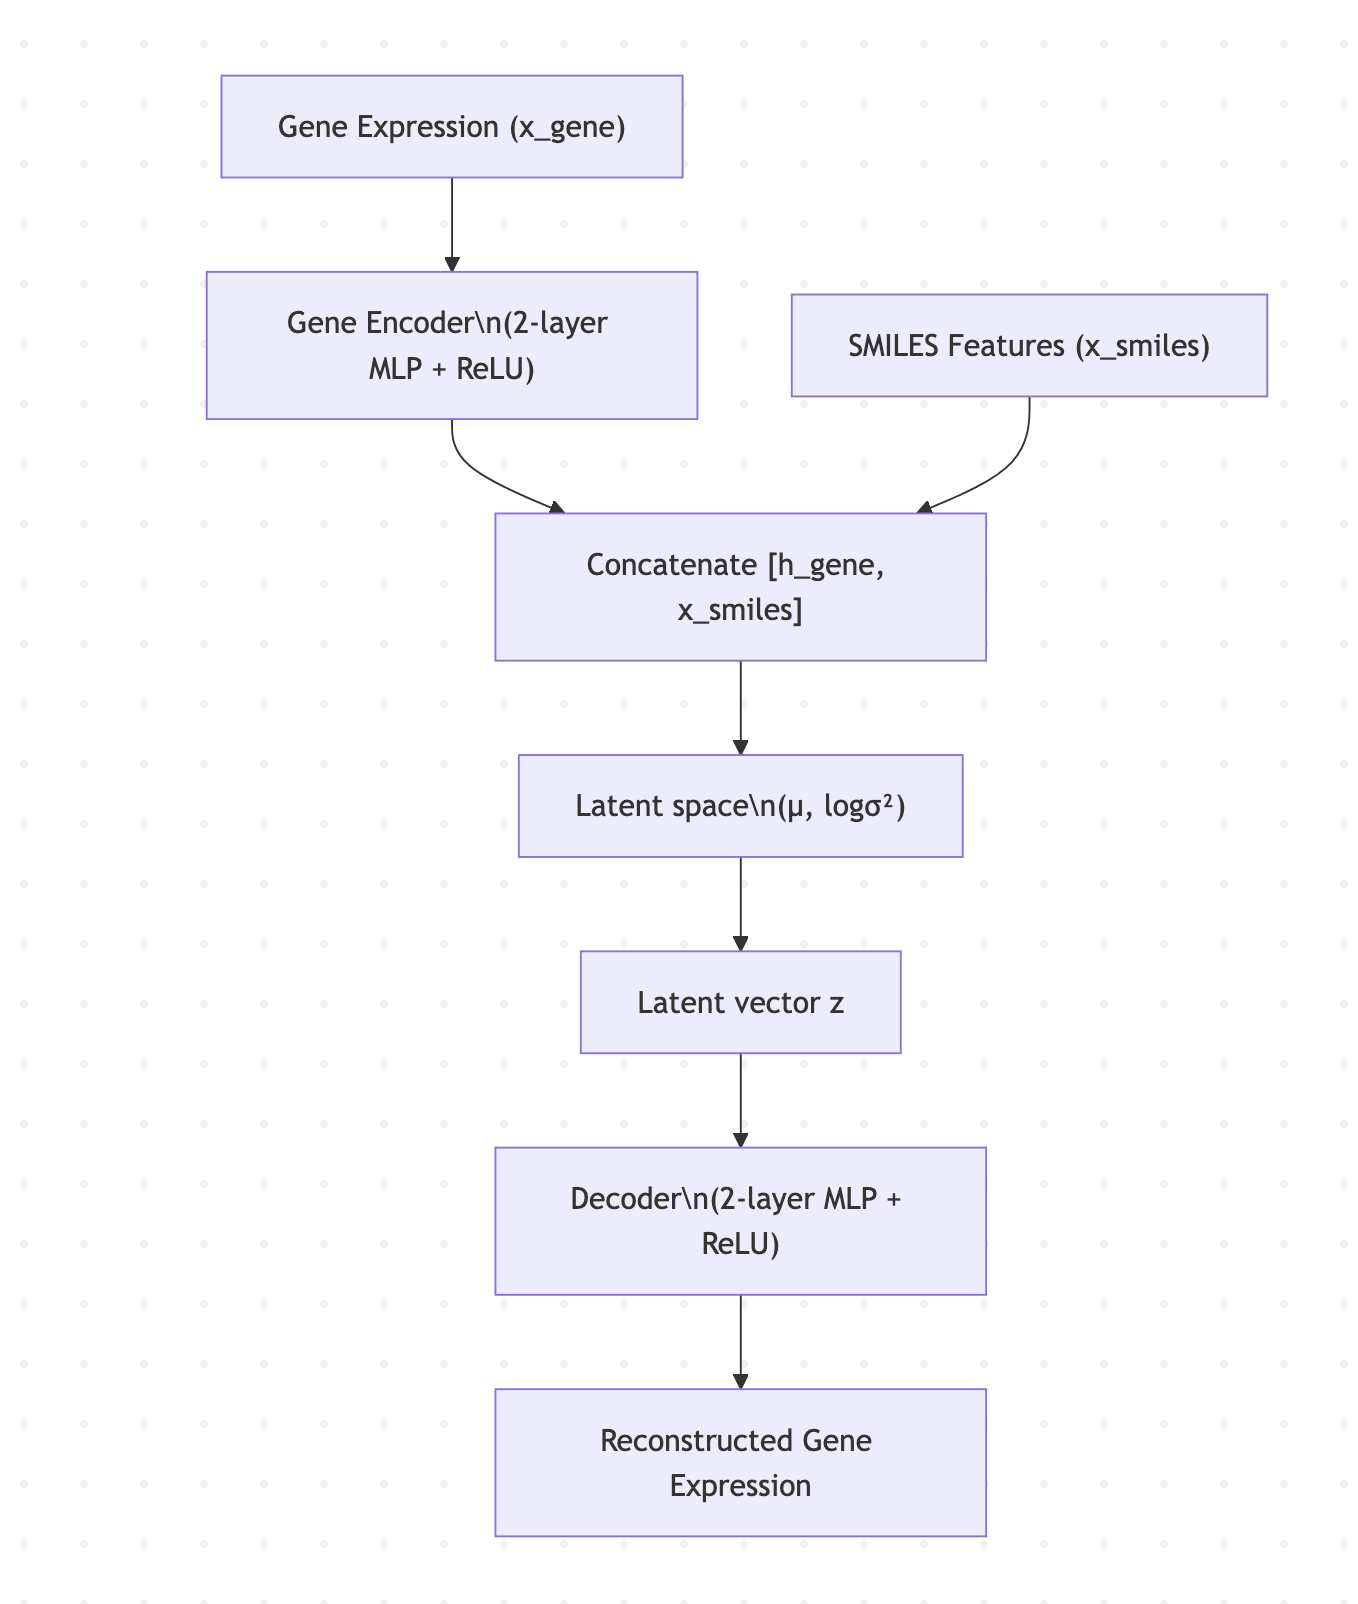

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
ls ../

__pycache__/              GDSC_genes.json           TCGA_genes.json
Aug8_nsc_cid_smiles.csv   models/                   TCGA_top_genes.json
code_ae_data/             name2smiles.txt.gz        tcga_w_RECIST.csv
coexisted_genes.ipynb     patient_data.py           tmp.csv
coexisted_top_genes.json  prep/                     VAE_GDSC.py
dataset/                  pyproject.toml            VAE_TCGA.py
for_vec2vec.ipynb         README.md
GDSC_all_genes.json       TCGA_all_genes.json


In [7]:
patients = pd.read_csv("../dataset/tcga/patients_info.csv.gz", index_col=0)
patients.head()

,project.project_id,cases.submitter_id,diagnoses.primary_diagnosis,treatments.therapeutic_agents,treatments.treatment_outcome,recist_label
0,TCGA-ACC,TCGA-OR-A5LL,Adrenal cortical carcinoma,Mitotane,'--,Unknown
1,TCGA-ACC,TCGA-OR-A5J7,Adrenal cortical carcinoma,Mitotane,Progressive Disease,0
2,TCGA-ACC,TCGA-P6-A5OG,"Osteosarcoma, NOS",Cisplatin,'--,Unknown
3,TCGA-ACC,TCGA-P6-A5OG,"Osteosarcoma, NOS",Methotrexate,'--,Unknown
4,TCGA-ACC,TCGA-P6-A5OG,"Osteosarcoma, NOS",Doxorubicin Hydrochloride,'--,Unknown


In [8]:
gene_exp = pd.read_csv("../dataset/tcga/gene_exp.csv.gz", index_col=0)
gene_exp.head()

,cases.submitter_id,A1BG,A1CF,A2M,A2ML1,A4GALT,AADAC,AADAT,AAMDC,AARD,...,ZNRF1,ZNRF3,ZP3,ZSCAN16,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZWINT,ZYX
0,TCGA-OR-A5LL,-0.738092,-0.358870,-1.284365,-0.662174,0.071062,3.991963,-1.507429,1.583545,1.452026,...,-0.035460,1.290558,-0.139355,-0.702613,-0.926827,0.604661,2.004361,-0.153295,-2.592235,-2.581243
1,TCGA-OR-A5J7,-0.579841,-0.383298,0.212061,-0.623405,-0.529421,-0.373526,-0.889172,4.461764,-0.721811,...,-0.683420,-0.812266,0.572096,-1.386444,-1.057613,-0.939411,0.140052,-0.955229,1.017702,-2.477875
2,TCGA-P6-A5OG,0.501267,-0.398130,0.612546,-0.707374,0.259546,-0.645832,0.036936,0.411848,-0.234271,...,0.116916,-1.172864,0.172997,-0.706474,0.292523,-2.336994,-1.764806,2.105068,1.142628,0.313311
6,TCGA-OR-A5J8,-0.618988,-0.398130,1.094105,-0.583765,1.155041,-0.674528,0.556963,0.336370,-0.568160,...,0.230676,-0.589812,-1.316566,-1.685373,0.263213,-1.948473,0.314336,-0.533601,0.018025,1.441010
7,TCGA-OR-A5JL,-0.575393,-0.309081,-0.257670,-0.000349,-0.863802,-0.056424,-0.560281,0.497837,-0.535787,...,-1.027671,0.259928,0.202159,-1.497237,-0.230091,0.249226,1.426306,-1.209736,-0.579039,-2.153090


In [9]:
df = patients.merge(gene_exp)
df.head()

,project.project_id,cases.submitter_id,diagnoses.primary_diagnosis,treatments.therapeutic_agents,treatments.treatment_outcome,recist_label,A1BG,A1CF,A2M,A2ML1,...,ZNRF1,ZNRF3,ZP3,ZSCAN16,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZWINT,ZYX
0,TCGA-ACC,TCGA-OR-A5LL,Adrenal cortical carcinoma,Mitotane,'--,Unknown,-0.738092,-0.358870,-1.284365,-0.662174,...,-0.035460,1.290558,-0.139355,-0.702613,-0.926827,0.604661,2.004361,-0.153295,-2.592235,-2.581243
1,TCGA-ACC,TCGA-OR-A5J7,Adrenal cortical carcinoma,Mitotane,Progressive Disease,0,-0.579841,-0.383298,0.212061,-0.623405,...,-0.683420,-0.812266,0.572096,-1.386444,-1.057613,-0.939411,0.140052,-0.955229,1.017702,-2.477875
2,TCGA-ACC,TCGA-P6-A5OG,"Osteosarcoma, NOS",Cisplatin,'--,Unknown,0.501267,-0.398130,0.612546,-0.707374,...,0.116916,-1.172864,0.172997,-0.706474,0.292523,-2.336994,-1.764806,2.105068,1.142628,0.313311
3,TCGA-ACC,TCGA-P6-A5OG,"Osteosarcoma, NOS",Methotrexate,'--,Unknown,0.501267,-0.398130,0.612546,-0.707374,...,0.116916,-1.172864,0.172997,-0.706474,0.292523,-2.336994,-1.764806,2.105068,1.142628,0.313311
4,TCGA-ACC,TCGA-P6-A5OG,"Osteosarcoma, NOS",Doxorubicin Hydrochloride,'--,Unknown,0.501267,-0.398130,0.612546,-0.707374,...,0.116916,-1.172864,0.172997,-0.706474,0.292523,-2.336994,-1.764806,2.105068,1.142628,0.313311


In [10]:
exp = df.iloc[:, 6:]
exp.head()

,A1BG,A1CF,A2M,A2ML1,A4GALT,AADAC,AADAT,AAMDC,AARD,AASS,...,ZNRF1,ZNRF3,ZP3,ZSCAN16,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZWINT,ZYX
0,-0.738092,-0.358870,-1.284365,-0.662174,0.071062,3.991963,-1.507429,1.583545,1.452026,1.876008,...,-0.035460,1.290558,-0.139355,-0.702613,-0.926827,0.604661,2.004361,-0.153295,-2.592235,-2.581243
1,-0.579841,-0.383298,0.212061,-0.623405,-0.529421,-0.373526,-0.889172,4.461764,-0.721811,0.411963,...,-0.683420,-0.812266,0.572096,-1.386444,-1.057613,-0.939411,0.140052,-0.955229,1.017702,-2.477875
2,0.501267,-0.398130,0.612546,-0.707374,0.259546,-0.645832,0.036936,0.411848,-0.234271,1.166155,...,0.116916,-1.172864,0.172997,-0.706474,0.292523,-2.336994,-1.764806,2.105068,1.142628,0.313311
3,0.501267,-0.398130,0.612546,-0.707374,0.259546,-0.645832,0.036936,0.411848,-0.234271,1.166155,...,0.116916,-1.172864,0.172997,-0.706474,0.292523,-2.336994,-1.764806,2.105068,1.142628,0.313311
4,0.501267,-0.398130,0.612546,-0.707374,0.259546,-0.645832,0.036936,0.411848,-0.234271,1.166155,...,0.116916,-1.172864,0.172997,-0.706474,0.292523,-2.336994,-1.764806,2.105068,1.142628,0.313311


In [11]:
j = pd.DataFrame({"treatment": df["treatments.therapeutic_agents"].unique()})


def to_parent(name):
    replacements = [
        " Hydrochloride",
        " Acetate",
        " Disodium",
        " Sodium",
        " Tartrate",
        " Citrate",
        " Pamoate",
        " Phosphate",
        " Tosylate",
        " Mesylate",
        " Poliglumex",
    ]
    for rpl in replacements:
        if name.endswith(rpl):
            return name.replace(rpl, "")
    return name


j["parent"] = j["treatment"].apply(to_parent)
j

,treatment,parent
0,Mitotane,Mitotane
1,Cisplatin,Cisplatin
2,Methotrexate,Methotrexate
3,Doxorubicin Hydrochloride,Doxorubicin
4,Carboplatin,Carboplatin
...,...,...
267,Broxuridine,Broxuridine
268,Aminocamptothecin,Aminocamptothecin
269,Vincristine Sulfate,Vincristine Sulfate
270,Nimustine,Nimustine


In [12]:
r = pd.read_csv("../Aug8_nsc_cid_smiles.csv", index_col=0)[["NAME", "SMILES"]].dropna()
tmp = pd.read_csv(
    "/Users/inouey2/Downloads/115781217722214650.txt.gz", sep="\t", header=None
).drop_duplicates()
tmp.columns = ["NAME", "SMILES"]
data = {
    "Taxane Compound": "C[C@@H]1CCC[C@@]2([C@@H]1C[C@@H]3CC[C@H]([C@@H](C3(C)C)CC2)C)C",
    "Gamma-Secretase Inhibitor RO4929097": "CC(C)(C(=O)NCC(C(F)(F)F)(F)F)C(=O)N[C@H]1C2=CC=CC=C2C3=CC=CC=C3NC1=O",
    "Akt Inhibitor MK2206": "C1CC(C1)(C2=CC=C(C=C2)C3=C(C=C4C(=N3)C=CN5C4=NNC5=O)C6=CC=CC=C6)N",
    "Pan-VEGFR/TIE2 Tyrosine Kinase Inhibitor CEP-11981": "CC(C)CN1C2=C(C=C(C=C2)NC3=NC=CC=N3)C4=C1C5=C(C6=CN(N=C6CC5)C)C7=C4CNC7=O",
    "Carmustine Implant": "C(CCl)NC(=O)N(CCCl)N=O",
    "Aurora Kinase/VEGFR2 Inhibitor CYC116": "CC1=C(SC(=N1)N)C2=NC(=NC=C2)NC3=CC=C(C=C3)N4CCOCC4",
}

q = pd.DataFrame(list(data.items()), columns=["NAME", "SMILES"])
r = pd.concat([r, tmp, q])
j = j.merge(r, left_on="parent", right_on="NAME", how="left")

In [13]:
j[["treatment", "SMILES"]]

,treatment,SMILES
0,Mitotane,C1=CC=C(C(=C1)C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl
1,Cisplatin,N.N.Cl[Pt]Cl
2,Methotrexate,CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C...
3,Doxorubicin Hydrochloride,CC1C(C(CC(O1)OC2CC(CC3=C2C(=C4C(=C3O)C(=O)C5=C...
4,Doxorubicin Hydrochloride,CC1C(C(CC(O1)OC2CC(CC3=C2C(=C4C(=C3O)C(=O)C5=C...
...,...,...
318,Broxuridine,C1[C@@H]([C@H](O[C@H]1N2C=C(C(=O)NC2=O)Br)CO)O
319,Aminocamptothecin,CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=C(C=CC=C5N...
320,Vincristine Sulfate,CC[C@@]1(C[C@@H]2C[C@@](C3=C(CCN(C2)C1)C4=CC=C...
321,Nimustine,CC1=NC=C(C(=N1)N)CNC(=O)N(CCCl)N=O


In [14]:
df = (
    df.merge(
        j[["treatment", "SMILES"]],
        left_on="treatments.therapeutic_agents",
        right_on="treatment",
        how="left",
    )
    .dropna()
    .drop_duplicates()
)

In [18]:
# 学習済みモデルの指定（ChemBERTa）
MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"

# トークナイザーとモデルをロード
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# GPUが使える場合はGPUに
model.to(device)

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(767, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-5): 6 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

In [19]:
# SMILESサンプル
smiles_list = df["SMILES"].unique().tolist()

# トークナイズ
inputs = tokenizer(smiles_list, padding=True, truncation=True, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# モデルからEmbeddingを取得（[CLS]トークンのベクトルを使用）
with torch.no_grad():
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]

In [20]:
drugs = pd.DataFrame(embeddings)
drugs.index = smiles_list
drugs

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
C1=CC=C(C(=C1)C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.256670,1.405213,-0.364212,-0.035530,0.269603,-0.404146,-0.026593,-0.976103,0.219688,-0.126748,...,0.822734,-0.607628,0.061183,0.434021,0.641774,2.536827,-1.282408,-0.078859,-0.564640,1.524515
N.N.Cl[Pt]Cl,0.251643,-0.451214,0.181128,-0.292302,-0.904642,-0.467247,-2.214640,0.467696,-0.926572,0.241438,...,0.391105,0.910863,1.818678,-0.263931,0.189872,0.034988,-0.298132,-1.783545,-1.084545,1.926415
CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C(=O)NC(CCC(=O)O)C(=O)O,-0.352312,-0.198618,-1.086231,-0.414215,0.579081,-0.031454,-0.524358,-0.399156,-0.223722,0.427816,...,0.899148,0.195638,-0.162159,-1.256228,0.262386,0.642164,-0.577411,-1.157745,-0.450073,0.221849
CC1C(C(CC(O1)OC2CC(CC3=C2C(=C4C(=C3O)C(=O)C5=C(C4=O)C(=CC=C5)OC)O)(C(=O)CO)O)N)O.Cl,0.882597,0.470835,-1.422988,-0.319964,-0.517546,-1.466612,-0.292151,-0.740454,-0.714448,-0.305721,...,0.698563,-0.570799,0.774689,-1.545114,0.580027,0.165596,-0.531548,-1.010598,0.632702,0.267384
CC1C(C(CC(O1)OC2CC(CC3=C2C(=C4C(=C3O)C(=O)C5=C(C4=O)C(=CC=C5)OC)O)(C(=O)CO)O)N)O,0.783080,0.356694,-1.418632,-0.377595,-0.313848,-1.378118,-0.171033,-0.711203,-0.641947,-0.314305,...,0.639011,-0.671777,0.553788,-1.591422,0.603833,0.235602,-0.705800,-1.012435,0.611622,0.265351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CC1=C(C=NO1)C(=O)NC2=CC=C(C=C2)C(F)(F)F,1.137035,-0.077371,-0.697802,0.971837,1.631202,-0.996160,0.209984,-0.626506,-0.990432,-1.022554,...,1.906049,-1.399688,0.715511,-0.761924,0.330761,0.900738,-1.112913,-1.229282,-0.237029,1.345452
C1[C@@H]([C@H](O[C@H]1N2C=C(C(=O)NC2=O)Br)CO)O,0.938857,0.112702,-0.001957,-1.506404,-0.503301,-0.805085,-0.835615,0.949241,-1.936699,0.272010,...,0.993996,-0.125469,2.174323,-0.314296,1.283156,0.639694,-0.956983,-0.328078,-0.963064,0.743120
CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=C(C=CC=C5N=C4C3=C2)N)O,0.747546,0.660119,-1.164023,0.489694,-0.617071,-1.076229,-0.743855,-0.280651,-0.794722,-0.819422,...,0.778769,-0.963377,0.887744,-0.798657,0.298918,1.019625,-0.773863,-0.979200,-0.513231,1.125086
CC[C@@]1(C[C@@H]2C[C@@](C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(C=C6C(=C5)[C@]78CCN9[C@H]7[C@@](C=CC9)([C@H]([C@@]([C@@H]8N6C=O)(C(=O)OC)O)OC(=O)C)CC)OC)C(=O)OC)O.OS(=O)(=O)O,1.081980,0.275858,-0.317046,-0.379736,-0.825421,-1.314194,-1.328754,0.206525,-0.971192,-0.776478,...,0.797913,-0.625920,1.637390,-1.333223,0.089040,-0.403051,-0.405031,-0.663823,0.269685,0.728454


In [24]:
ls

_data_statistics.ipynb  preprocess_GDSC.ipynb   VAE_TCGA.ipynb
_stat_TCGA.ipynb        preprocess_TCGA.ipynb
models/                 VAE_GDSC.ipynb


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [29]:
from VAE_TCGA import GeneSMILESVAE

In [21]:
gene_exp_values = gene_exp.iloc[:, 1:].values.astype(np.float32)

# DataFrame に戻す
gene_exp_values = pd.DataFrame(
    gene_exp_values, columns=gene_exp.columns[1:], index=gene_exp["cases.submitter_id"]
)

gene_list = []
drug_list = []

for idx, row in df.iterrows():
    patient = row["cases.submitter_id"]
    drug = row["SMILES"]

    if patient not in gene_exp_values.index or drug not in drugs.index:
        continue  # 存在しない場合はスキップ

    x_gene = gene_exp_values.loc[patient].values
    x_drug = drugs.loc[drug].values

    gene_list.append(x_gene)
    drug_list.append(x_drug)

x_gene_tensor = torch.tensor(gene_list, dtype=torch.float32).to(device)
x_drug_tensor = torch.tensor(drug_list, dtype=torch.float32).to(device)

/var/folders/y3/ssnk1ytd3m5bjmrchh2lt74srg76p8/T/ipykernel_25082/3628918432.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  x_gene_tensor = torch.tensor(gene_list, dtype=torch.float32).to(device)


In [27]:
# ===== Validation 用の分割 =====
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# CPU に一旦出して numpy 化（train_test_split のため）
Xg = x_gene_tensor.detach().cpu().numpy()
Xd = x_drug_tensor.detach().cpu().numpy()

# ランダム分割（各行が独立前提）
Xg_tr, Xg_val, Xd_tr, Xd_val = train_test_split(
    Xg, Xd, test_size=0.2, random_state=42, shuffle=True
)

# Tensor へ戻す（学習は GPU/CPU どちらでもOK）
train_gene = torch.tensor(Xg_tr,  dtype=torch.float32).to(device)
train_drug = torch.tensor(Xd_tr,  dtype=torch.float32).to(device)
val_gene   = torch.tensor(Xg_val, dtype=torch.float32).to(device)
val_drug   = torch.tensor(Xd_val, dtype=torch.float32).to(device)

# DataLoader（元の dl を置き換え）
train_dl = DataLoader(
    TensorDataset(train_gene, train_drug),
    batch_size=256, shuffle=True, drop_last=False, num_workers=0
)
val_dl = DataLoader(
    TensorDataset(val_gene, val_drug),
    batch_size=256, shuffle=False, drop_last=False, num_workers=0
)

In [30]:
import os

os.makedirs("models/tcga", exist_ok=True)  # 保存ディレクトリを作成

# Input dimensions
gene_dim = x_gene_tensor.shape[1]
smiles_dim = x_drug_tensor.shape[1]
latent_dim = 128

# Model
vae = GeneSMILESVAE(gene_dim, smiles_dim, latent_dim).to(device)

# Optimizer
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

# ====== Training config ======
num_epochs = 150
C_max = 10.0
C_steps = 30
gamma = 5.0

use_freebits = False
tau = 0.02
max_grad_norm = 5.0

from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=8, verbose=True
)

# ---- 保存管理 ----
best_elbo = float("inf")
best_path = "models/tcga/tcga_best.pt"

for epoch in range(num_epochs):
    vae.train()
    epoch_recon = epoch_kl = epoch_elbo = 0.0
    n_batches = 0

    C = C_max * min(1.0, epoch / C_steps)

    # ---- Train ----
    for xb_gene, xb_drug in train_dl:
        xb_gene = xb_gene.to(device, non_blocking=True)
        xb_drug = xb_drug.to(device, non_blocking=True)

        optimizer.zero_grad()
        recon, mu, logvar = vae(xb_gene, xb_drug)

        recon_loss = F.mse_loss(recon, xb_gene, reduction="mean")
        kl_per_dim = 0.5 * (-1 - logvar + mu.pow(2) + logvar.exp())  # (B,D)
        kl_raw = kl_per_dim.sum(dim=1).mean()  # nats/sample

        if use_freebits:
            kl_fb = torch.clamp(kl_per_dim.mean(dim=0), min=tau).sum()
            loss = recon_loss + gamma * torch.abs(kl_fb - C)
        else:
            loss = recon_loss + gamma * torch.abs(kl_raw - C)

        loss.backward()
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_grad_norm)
        optimizer.step()

        epoch_recon += recon_loss.item()
        epoch_kl    += kl_raw.item()
        epoch_elbo  += recon_loss.item() + kl_raw.item()
        n_batches   += 1

    tr_recon = epoch_recon / n_batches
    tr_kl    = epoch_kl / n_batches
    tr_elbo  = epoch_elbo / n_batches

    # ---- Validation ----
    vae.eval()
    with torch.no_grad():
        val_recon = val_kl = val_elbo = 0.0
        val_batches = 0
        for vb_gene, vb_drug in val_dl:
            vb_gene = vb_gene.to(device, non_blocking=True)
            vb_drug = vb_drug.to(device, non_blocking=True)

            recon, mu, logvar = vae(vb_gene, vb_drug)

            r = F.mse_loss(recon, vb_gene, reduction="mean")
            kld = 0.5 * (-1 - logvar + mu.pow(2) + logvar.exp()).sum(dim=1).mean()

            val_recon += r.item()
            val_kl    += kld.item()
            val_elbo  += r.item() + kld.item()
            val_batches += 1

        val_recon /= val_batches
        val_kl    /= val_batches
        val_elbo  /= val_batches

    # 学習率調整は Validation ELBO で
    scheduler.step(val_elbo)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train -> Recon:{tr_recon:.4f} KL:{tr_kl:.4f} ELBO:{tr_elbo:.4f} | "
        f"Val -> Recon:{val_recon:.4f} KL:{val_kl:.4f} ELBO:{val_elbo:.4f} | C:{C:.2f}"
    )

    # ---- 保存は Validation 基準 ----
    if val_elbo < best_elbo - 1e-4:
        best_elbo = val_elbo
        torch.save(vae.state_dict(), best_path)
        print(f"[Save] Best model updated at epoch {epoch+1}: {best_path}")

    # （任意）スナップショット
    if (epoch + 1) % 10 == 0:
        torch.save(vae.state_dict(), f"models/tcga/tcga_epoch{epoch+1}.pt")

# 最後に last を保存
torch.save(vae.state_dict(), "models/tcga/tcga_last.pt")
print("Saved final model: models/tcga/tcga_last.pt")

/Users/inouey2/miniconda3/envs/torch/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/150 | Train -> Recon:1.0013 KL:0.2321 ELBO:1.2334 | Val -> Recon:0.9891 KL:0.0619 ELBO:1.0510 | C:0.00
[Save] Best model updated at epoch 1: models/tcga/tcga_best.pt
Epoch 2/150 | Train -> Recon:0.9931 KL:0.3154 ELBO:1.3086 | Val -> Recon:0.9850 KL:0.3066 ELBO:1.2916 | C:0.33
Epoch 3/150 | Train -> Recon:0.9898 KL:0.6421 ELBO:1.6318 | Val -> Recon:0.9836 KL:0.5580 ELBO:1.5416 | C:0.67
Epoch 4/150 | Train -> Recon:0.9852 KL:1.0274 ELBO:2.0126 | Val -> Recon:0.9829 KL:0.9024 ELBO:1.8853 | C:1.00
Epoch 5/150 | Train -> Recon:0.9867 KL:1.3011 ELBO:2.2878 | Val -> Recon:0.9820 KL:1.1535 ELBO:2.1355 | C:1.33
Epoch 6/150 | Train -> Recon:0.9861 KL:1.6419 ELBO:2.6280 | Val -> Recon:0.9805 KL:1.6561 ELBO:2.6366 | C:1.67
Epoch 7/150 | Train -> Recon:0.9837 KL:2.0206 ELBO:3.0043 | Val -> Recon:0.9799 KL:1.8643 ELBO:2.8441 | C:2.00
Epoch 8/150 | Train -> Recon:0.9834 KL:2.3241 ELBO:3.3075 | Val -> Recon:0.9792 KL:2.3963 ELBO:3.3755 | C:2.33
Epoch 9/150 | Train -> Recon:0.9800 KL:2.6414 ELB

In [20]:
vae.eval()

with torch.no_grad():
    mu, logvar = vae.encode(x_gene_tensor, x_drug_tensor)

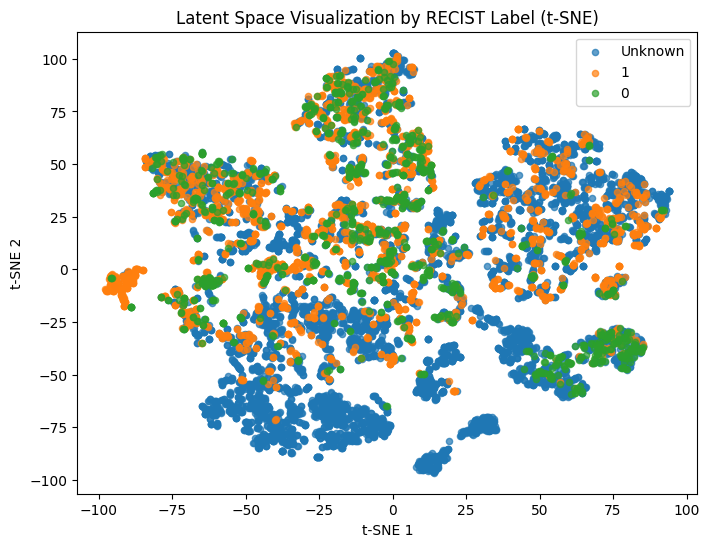

In [21]:
z_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    mu.cpu().numpy()
)

# 可視化
plt.figure(figsize=(8, 6))
# ここでは response ラベルなどがあれば色分け可能
# 例: df['recist_label']
labels = df["recist_label"].values  # もしラベルがある場合
unique_labels = list(set(labels))
for lbl in unique_labels:
    idxs = labels == lbl
    plt.scatter(z_2d[idxs, 0], z_2d[idxs, 1], label=lbl, alpha=0.7, s=20)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Latent Space Visualization by RECIST Label (t-SNE)")
plt.legend()
plt.show()

/var/folders/y3/ssnk1ytd3m5bjmrchh2lt74srg76p8/T/ipykernel_66524/936310423.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20b', 33)  # 'tab20b' や 'tab20c' は色数が多い


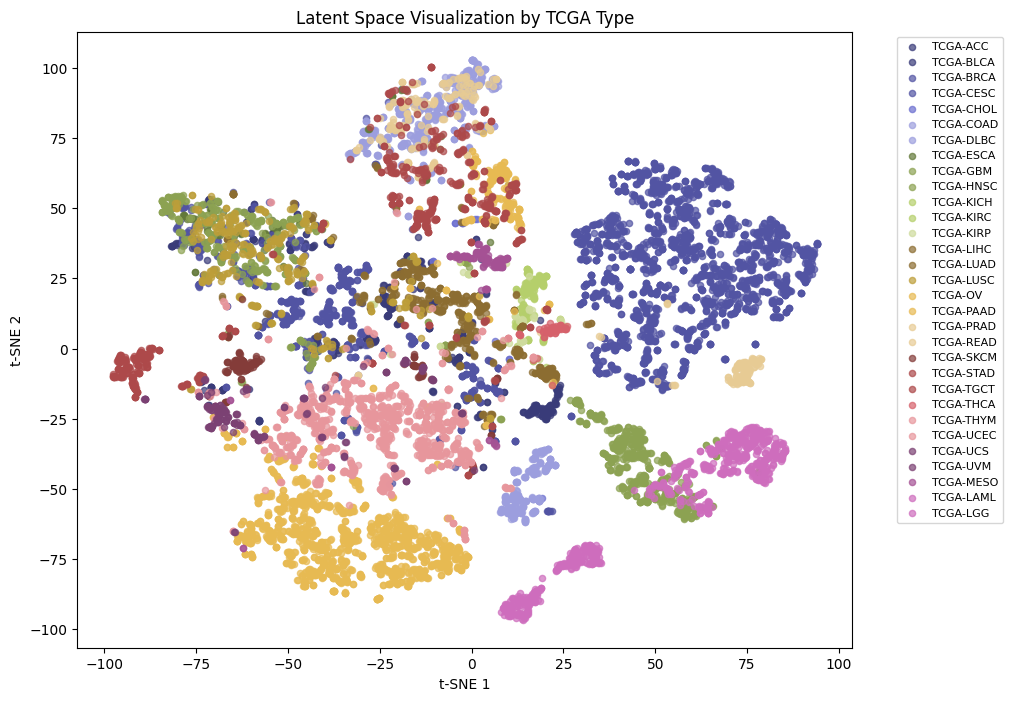

In [22]:
plt.figure(figsize=(10, 8))

tcga_types = df["project.project_id"].unique()
colors = plt.cm.get_cmap("tab20b", 33)

for i, tcga in enumerate(tcga_types):
    idxs = df["project.project_id"] == tcga
    plt.scatter(
        z_2d[idxs, 0], z_2d[idxs, 1], label=tcga, alpha=0.7, s=20, color=colors(i)
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Latent Space Visualization by TCGA Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.show()

/var/folders/y3/ssnk1ytd3m5bjmrchh2lt74srg76p8/T/ipykernel_66524/3811261581.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 20)


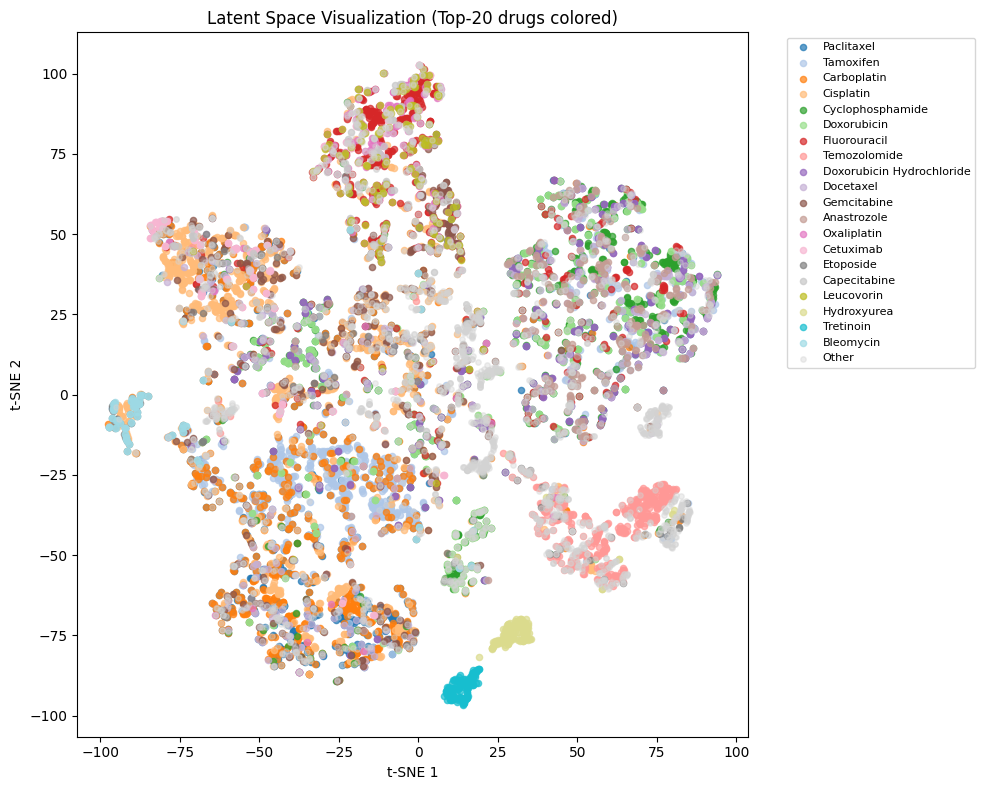

In [23]:
plt.figure(figsize=(10, 8))

counts = df["treatments.therapeutic_agents"].value_counts()
top20 = counts.head(20).index.tolist()
cmap = plt.cm.get_cmap("tab20", 20)

for i, drug in enumerate(top20):
    idxs = (df["treatments.therapeutic_agents"] == drug).values
    plt.scatter(
        z_2d[idxs, 0], z_2d[idxs, 1], label=drug, alpha=0.7, s=20, color=cmap(i)
    )

other_idxs = ~df["treatments.therapeutic_agents"].isin(top20).values
if np.any(other_idxs):
    plt.scatter(
        z_2d[other_idxs, 0],
        z_2d[other_idxs, 1],
        label="Other",
        alpha=0.4,
        s=15,
        color="lightgray",
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Latent Space Visualization (Top-20 drugs colored)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()